# Fig: Distribution of last h_actual in Infotaxis vs MAP comparison: pmax_th=0.95

Reference: 
- `20260531_fig_infotaxis_MAP_cmp_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from data_prep_plot.plot_utils import bar_violinplot_last_h_actual
from data_prep_plot.simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  514
Mean:    left: 0.122  right: 0.826
Median:  left: 0.120  right: 1.006

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  991    right:  545
Mean:    left: 0.189  right: 1.035
Median:  left: 0.149  right: 1.081

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  971    right:  534
Mean:    left: 0.263  right: 1.122
Median:  left: 0.253  right: 1.142

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  976    right:  501
Mean:    left: 0.319  right: 1.421
Median:  left: 0.316  right: 1.556

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


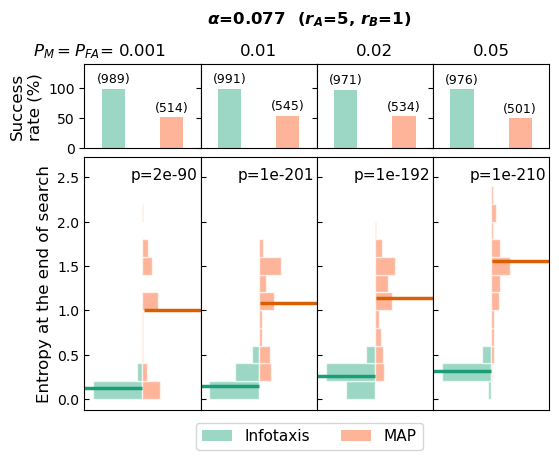

Samples: left:  977    right:  339
Mean:    left: 0.173  right: 1.395
Median:  left: 0.163  right: 1.230

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  974    right:  303
Mean:    left: 0.271  right: 1.840
Median:  left: 0.262  right: 1.923

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  969    right:  300
Mean:    left: 0.308  right: 2.179
Median:  left: 0.301  right: 2.313

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  959    right:  298
Mean:    left: 0.374  right: 2.430
Median:  left: 0.385  right: 2.465

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


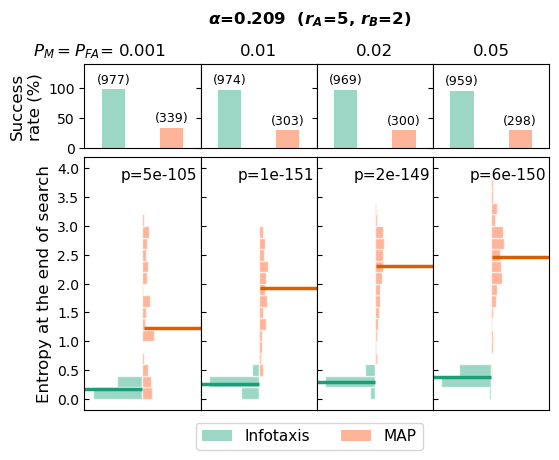

Samples: left:  986    right:  524
Mean:    left: 0.170  right: 0.839
Median:  left: 0.148  right: 1.006

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  985    right:  535
Mean:    left: 0.183  right: 1.019
Median:  left: 0.139  right: 1.081

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  968    right:  520
Mean:    left: 0.264  right: 1.112
Median:  left: 0.269  right: 1.142

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  967    right:  510
Mean:    left: 0.329  right: 1.424
Median:  left: 0.316  right: 1.559

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


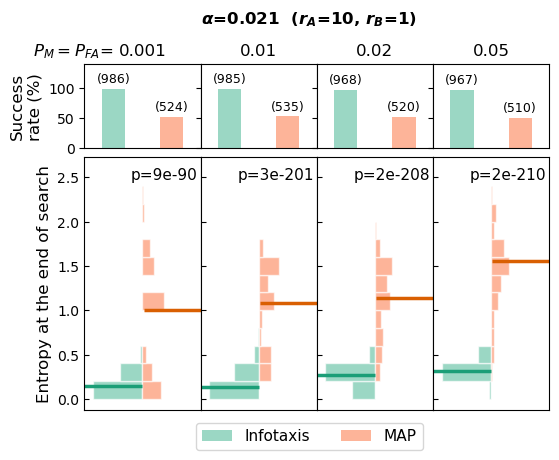

Samples: left:  980    right:  313
Mean:    left: 0.179  right: 1.477
Median:  left: 0.165  right: 1.513

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  966    right:  332
Mean:    left: 0.279  right: 1.902
Median:  left: 0.272  right: 1.986

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  968    right:  306
Mean:    left: 0.335  right: 2.236
Median:  left: 0.330  right: 2.386

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  961    right:  244
Mean:    left: 0.407  right: 2.592
Median:  left: 0.403  right: 2.689

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


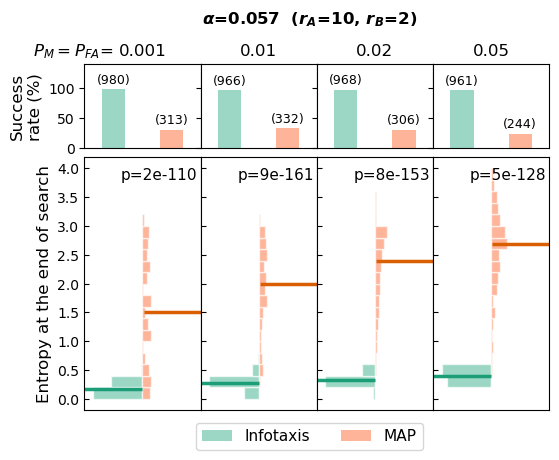

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_all = [0.001, 0.01, 0.02, 0.05]

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_MAP_match_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for pm in pm_all:
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        
        fig = bar_violinplot_last_h_actual(
            cr=cr, br=br, pm_all=pm_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Infotaxis", y_str="MAP",
            comparison_type="simple",
            stats_type="two-sided",
            bar_step=0.2,
            crowded_bars=False,
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            color_idx_left=0, color_idx_right=1,
            alpha=0.65
        )

        fig.savefig(
            path_fig / f"fig_last_h_actual_infotaxis_MAP_cmp_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )